In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
# sys.path.append('/home/mvargas/code/Huawei/survan')

from deep_lambda_cox import DeepLambdaSA
from lambda_cox import LambdaSA
from baseline_cox import SA

from utils import concordance_index, unroll_time, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
config_path = '../configs/config_lastfm.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [3]:
model = DeepLambdaSA(config, seed=42)

In [ ]:
model.data['ts'][11]

In [6]:
model.data['cs'][11]

True

In [7]:
train_gen, _ = model.get_train_test()

In [11]:
train_gen.cs.sum()/len(train_gen.cs)

0.7728171799943487

In [36]:
%%time
num_exps = 5
sizes = [.2]

ibs_is = np.zeros((num_exps, len(sizes)))
ibs_lm = np.zeros((num_exps, len(sizes)))

ci_is = np.zeros((num_exps, len(sizes)))
ci_lm = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_is[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_is[fold, i] = concordance_index(scores, ts, cs)

        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        ms = test_gen.mask
        
        _ = model.train(train_gen, test_gen)
        surv = model.survival_curve(seqs)
        ibs_lm[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        scores = model.scores(seqs, q=0.0)
        ci_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

 62%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                        | 125/200 [01:23<00:50,  1.49it/s]


KeyboardInterrupt: 

In [ ]:
%%time

num_exps = 5
sizes = [.2]
size = sizes[0]

bs_0 = np.zeros((num_exps, len(tgt_lrs)))
bs_1 = np.zeros((num_exps, len(tgt_lrs)))

ci_0 = np.zeros((num_exps, len(tgt_lrs)))
ci_1 = np.zeros((num_exps, len(tgt_lrs)))

for fold in range(num_exps):
    for i, tgt_lr in enumerate(tgt_lrs):
        config['target_lr'] = 0.1
        
        print(".", end="")
        
        # Landmarking.
        config['lambda_'] = .9
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_1[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:,0])
        ci_1[fold, i] = concordance_index(scores, ts, cs)

        # TCSR.
        config['lambda_'] = 0.0
        model = DeepLambdaSA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen)
        surv = model.survival_curve(seqs)
        bs_0[fold, i] = model.integrated_brier_score(surv[:,0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:,0])
        ci_0[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.....
.....
.....
..

In [15]:
config['landmark'] = True
config['num_epochs'] = 100
model = SA(config, seed=1)

In [16]:
train_gen, test_gen = model.get_train_test()

In [17]:
loss = model.train(train_gen, test_gen)

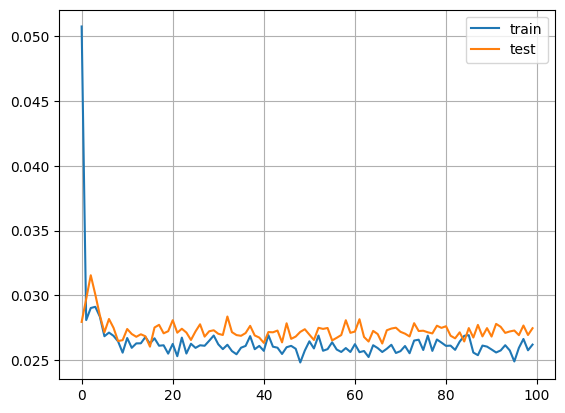

In [20]:
plt.plot(loss[0], label='train')
plt.plot(loss[1], label='test')
plt.legend()
plt.grid()

In [21]:
# plt.plot(tr_loss, label='train')
# plt.plot(te_loss, label='test')
# plt.legend()
# plt.grid()

In [29]:
seqs = train_gen.X
ts = train_gen.ts
cs = train_gen.cs

scores = model.scores(seqs, q=0.5)
concordance_index(scores, ts, cs)

0.4789497875946667

In [23]:
mask = train_gen.mask

In [24]:
mask[10].all(1).sum()

0

In [25]:
ts[10]

27

In [26]:
surv = model.survival_curve(seqs)
model.integrated_brier_score(surv[:,0], ts, cs)

Array(0.18061742, dtype=float32)

In [27]:
scurves = surv[:,0]

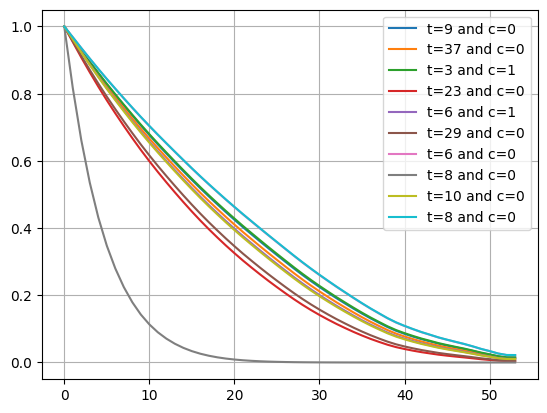

In [28]:
for i in range(10):
    plt.plot(scurves[i], label=f't={ts[i]} and c={cs[i]}')
plt.legend()
plt.grid()

array([[0.1, 0.3, 1.6, ..., 1.7, 1.3, 1.5],
       [0. , 0.8, 1.6, ..., 2.1, 2. , 2. ],
       [0. , 0.1, 0.8, ..., 0.7, 1.5, 1.4],
       ...,
       [0.1, 0.5, 2.1, ..., 1.6, 0.9, 1.6],
       [0. , 0.4, 1.4, ..., 1.8, 1.6, 1.7],
       [0. , 0.1, 2.9, ..., 2.3, 2.1, 2.2]])